CEL -> prognozę OZE - watr + słońce - OZE to sobie jeszcze sprawdzimy
ile z wiatru jesteśmy w stanie wygenerować energii na kolejne 24 godziny sądząc po samej prognozie pogody i danych historycznych z 2 lat
ile z słońca jesteśmy w stanie wygenerować energii na kolejne 24 godziny sądząc po samej prognozie pogody i danych historycznych z 2 lat
ale z jednego modelu

jaką granulację prognozy czy co godzinę czy na 24h - co godzinę lepsze
prognoz pogody możemy użyć na kolejny dzień - jeśli chodzi o test.

zakres danych od 2023 do 2025 - na tym trenowanie - modele różne (testujemy jako okno a nie tylko np ostatni miesiąc)


Z danych bierzemy słońce, wiatr, temperaturę oraz wilgotność

z tego https://transparency.entsoe.eu/load/total/dayAhead?appState=%7B"sa"%3A%5B"CTY%7C10YPL-AREA-----S"%5D%2C"st"%3A"CTY"%2C"mm"%3Afalse%2C"ma"%3Afalse%2C"sp"%3A"HALF"%2C"dt"%3A"CHART"%2C"df"%3A%5B"2026-01-01"%2C"2026-01-01"%5D%2C"tz"%3A"CET"%7D - ogarnąć klucz do API



In [ ]:
# Pogoda dla polski:


# pip install openmeteo-requests
# pip install requests-cache retry-requests numpy pandas

import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52,
	"longitude": 20,
	"hourly": "temperature_2m",
	"past_days": 0,
	"forecast_days": 7,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Prognoza generacji OZE w Polsce

* Wiktor Matla nr indeksu: 148896
* Bartłomiej Kachniarz nr indeksu: 76901

# 1. Wstęp

## 1.1 Zarys projektu

Cel: model sieci neuronowej prognozujący godzinową generację energii wiatrowej i fotowoltaicznej w KSE na 24h do przodu.

Wejście: prognoza pogody na kolejne 24h dla kilku punktów w Polsce + dane historyczne pogody i generacji 2023–2025.

Wyjście: jeden model, dwa targety (`wi`, `pv`), 24 godziny w przód, krok godzinowy.

## 1.2 Plan pracy

Projekt podzieliliśmy na następujące etapy (każdy odpowiada sekcji notebooka):

1. Wstęp
2. Dane — pobranie generacji OZE z PSE, pogody historycznej z Open-Meteo Archive, połączenie i czyszczenie
3. Eksploracyjna analiza danych — rozkłady, sezonowość, korelacje, outliery
4. Architektura sieci i procedura uczenia — baseline, MLP, LSTM seq2seq; podział walk-forward, strojenie hiperparametrów
5. Wyniki i porównanie modeli — metryki MAE/RMSE, analiza błędów
6. Podsumowanie

# 2. Dane

## 2.1 Generacja OZE z PSE

Źródło: API PSE, endpoint `his-wlk-cal` pod `https://api.raporty.pse.pl/api/his-wlk-cal`. Bez autoryzacji, JSON, filtr `$filter=business_date eq 'YYYY-MM-DD'`.

Interesujące pola:

| pole | opis |
|---|---|
| `dtime` | godzina lokalna (CET/CEST) |
| `wi` | generacja wiatrowa [MW] |
| `pv` | generacja PV [MW] |
| `demand` | zapotrzebowanie KSE [MW] |

Zakres: 2023-01-01 → 2025-12-31.

In [9]:
import time
from pathlib import Path
from datetime import date, timedelta

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("data/pse")
OUTPUT_DIR = Path("data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PSE_API_URL = "https://api.raporty.pse.pl/api/his-wlk-cal"
DATE_FROM = date(2023, 1, 1)
DATE_TO   = date(2025, 12, 31)

print(f"{DATE_FROM} -> {DATE_TO} ({(DATE_TO - DATE_FROM).days + 1} dni)")

2023-01-01 -> 2025-12-31 (1096 dni)


Importy, ścieżki na pliki cache i wynikowe, endpoint i zakres dat.

### 2.1.1 Pobieranie pojedynczego dnia

In [20]:
COLUMN_MAP = {
    "dtime":         "timestamp",
    "dtime_utc":     "timestamp_utc",
    "demand":        "zapotrzebowanie",
    "wi":            "wi",
    "pv":            "pv",
    "business_date": "business_date",
}

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
}


def fetch_pse_day(d: date, force: bool = False) -> pd.DataFrame:
    cache_file = DATA_DIR / f"his_wlk_cal_{d.isoformat()}.csv"
    if cache_file.exists() and not force:
        return pd.read_csv(cache_file, sep=";", parse_dates=["timestamp"])

    params = {"$filter": f"business_date eq '{d.isoformat()}'"}
    try:
        r = requests.get(PSE_API_URL, params=params, headers=HEADERS, timeout=30)
        r.raise_for_status()
        payload = r.json()
    except Exception as e:
        print(f"  [err] {d}: {type(e).__name__}: {e}")
        return pd.DataFrame()

    records = payload.get("value", [])
    if not records:
        print(f"  [empty] {d}")
        return pd.DataFrame()

    df = pd.DataFrame(records)
    keep = [c for c in COLUMN_MAP if c in df.columns]
    df = df[keep].rename(columns={c: COLUMN_MAP[c] for c in keep})
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"].astype(str).str.replace(r"(\d{2})[ab](:\d{2}:\d{2})", r"\1\2", regex=True))
    df = df.sort_values("timestamp").reset_index(drop=True)
    df.to_csv(cache_file, sep=";", index=False)
    return df


test_df = fetch_pse_day(date(2024, 6, 14))
print(f"wierszy: {len(test_df)}, kolumny: {list(test_df.columns)}")
test_df.head()

wierszy: 96, kolumny: ['timestamp', 'timestamp_utc', 'zapotrzebowanie', 'wi', 'pv', 'business_date']


,timestamp,timestamp_utc,zapotrzebowanie,wi,pv,business_date
0,2024-06-14 00:15:00,2024-06-13 22:15:00,16295.296,299.813,0.0,2024-06-14
1,2024-06-14 00:30:00,2024-06-13 22:30:00,15964.026,320.835,0.0,2024-06-14
2,2024-06-14 00:45:00,2024-06-13 22:45:00,15772.470,341.506,0.0,2024-06-14
3,2024-06-14 01:00:00,2024-06-13 23:00:00,15695.535,349.510,0.0,2024-06-14
4,2024-06-14 01:15:00,2024-06-13 23:15:00,15606.192,362.899,0.0,2024-06-14


Funkcja pobiera dane dla jednego dnia, zostawia tylko interesujące nas kolumny i zapisuje do CSV. Smoke test na 14.06.2024.

### 2.1.2 Pełny zakres 2023–2025

In [21]:
def daterange(start: date, end: date):
    for i in range((end - start).days + 1):
        yield start + timedelta(days=i)


def fetch_pse_range(start: date, end: date, sleep_s: float = 0.1) -> pd.DataFrame:
    all_days = list(daterange(start, end))
    print(f"Pobieranie {len(all_days)} dni...")

    frames, failed = [], []
    for i, d in enumerate(all_days, 1):
        df = fetch_pse_day(d)
        if df.empty:
            failed.append(d)
        else:
            frames.append(df)
        if i % 30 == 0 or i == len(all_days):
            print(f"  [{i:>4}/{len(all_days)}]  ok: {i - len(failed)}  err: {len(failed)}")
        time.sleep(sleep_s)

    if not frames:
        return pd.DataFrame()

    full = pd.concat(frames, ignore_index=True)
    full["timestamp"] = full["timestamp"].astype(str).str.replace(
        r"(\d{2})[ab](:\d{2}:\d{2})", r"\1\2", regex=True
    )
    full["timestamp"] = pd.to_datetime(full["timestamp"])
    full = full.sort_values("timestamp").reset_index(drop=True)

    print(f"\nwierszy: {len(full)}, nieudane dni: {len(failed)}")
    if failed:
        print(f"failed: {failed[:10]}{'...' if len(failed) > 10 else ''}")
    return full


df_raw = fetch_pse_range(DATE_FROM, DATE_TO)
df_raw.head()

Pobieranie 1096 dni...
  [empty] 2023-01-01
  [empty] 2023-01-02
  [empty] 2023-01-03
  [empty] 2023-01-04
  [empty] 2023-01-05
  [empty] 2023-01-06
  [empty] 2023-01-07
  [empty] 2023-01-08
  [empty] 2023-01-09
  [empty] 2023-01-10
  [empty] 2023-01-11
  [empty] 2023-01-12
  [empty] 2023-01-13
  [empty] 2023-01-14
  [empty] 2023-01-15
  [empty] 2023-01-16
  [empty] 2023-01-17
  [empty] 2023-01-18
  [empty] 2023-01-19
  [empty] 2023-01-20
  [empty] 2023-01-21
  [empty] 2023-01-22
  [empty] 2023-01-23
  [empty] 2023-01-24
  [empty] 2023-01-25
  [empty] 2023-01-26
  [empty] 2023-01-27
  [empty] 2023-01-28
  [empty] 2023-01-29
  [empty] 2023-01-30
  [  30/1096]  ok: 0  err: 30
  [empty] 2023-01-31
  [empty] 2023-02-01
  [empty] 2023-02-02
  [empty] 2023-02-03
  [empty] 2023-02-04
  [empty] 2023-02-05
  [empty] 2023-02-06
  [empty] 2023-02-07
  [empty] 2023-02-08
  [empty] 2023-02-09
  [empty] 2023-02-10
  [empty] 2023-02-11
  [empty] 2023-02-12
  [empty] 2023-02-13
  [empty] 2023-02-14
  

,timestamp,timestamp_utc,zapotrzebowanie,wi,pv,business_date
0,2024-06-14 00:00:00,2024-06-13 22:00:00,15498.469,296.576,0.0,2024-06-13
1,2024-06-14 00:15:00,2024-06-13 22:15:00,16295.296,299.813,0.0,2024-06-14
2,2024-06-14 00:30:00,2024-06-13 22:30:00,15964.026,320.835,0.0,2024-06-14
3,2024-06-14 00:45:00,2024-06-13 22:45:00,15772.470,341.506,0.0,2024-06-14
4,2024-06-14 01:00:00,2024-06-13 23:00:00,15695.535,349.510,0.0,2024-06-14


API zwraca dane od 2024-06-14, wcześniejsze daty są niedostępne. Dane sprzed tej daty pobraliśmy ręcznie ze [strony archiwum PSE](https://www.pse.pl/dane-systemowe/funkcjonowanie-kse/raporty-dobowe-z-pracy-kse/generacja-zrodel-wiatrowych) jako miesięczne CSV-ki, które leżą w `data/pse_archiwum/`.

### 2.1.3 Wczytanie archiwum (2023-01-01 → 2024-06-13)

In [ ]:
ARCHIVE_DIR = Path("data/pse_archiwum")
files = sorted(ARCHIVE_DIR.glob("*.csv"))

frames = [pd.read_csv(f, sep=";", encoding="windows-1250", decimal=",") for f in files]
df_archive = pd.concat(frames, ignore_index=True)
df_archive.columns = ["data", "godzina", "wi", "pv"]

df_archive["godzina"] = df_archive["godzina"].astype(str).str.replace(r"[abAB]", "", regex=True).astype(int)

df_archive["timestamp"] = pd.to_datetime(df_archive["data"]) + pd.to_timedelta(df_archive["godzina"] - 1, unit="h")
df_archive = df_archive[["timestamp", "wi", "pv"]].sort_values("timestamp").reset_index(drop=True)

print(f"plików: {len(files)}, wierszy: {len(df_archive)}")
print(f"zakres: {df_archive['timestamp'].min()} -> {df_archive['timestamp'].max()}")
df_archive.head()

plików: 18, wierszy: 12719
zakres: 2023-01-01 00:00:00 -> 2024-06-13 23:00:00


,timestamp,wi,pv
0,2023-01-01 00:00:00,5529.188,0.0
1,2023-01-01 01:00:00,4250.700,0.0
2,2023-01-01 02:00:00,3124.613,0.0
3,2023-01-01 03:00:00,3486.663,0.0
4,2023-01-01 04:00:00,4257.800,0.0


Wczytanie i sklejenie miesięcznych CSV-ek. Godziny 1–24 z PSE konwertujemy na timestamp (godzina 1 = 00:00).

### 2.1.4 Agregacja API i sklejenie z archiwum

In [ ]:
df_api = df_raw.copy()
df_api["timestamp"] = pd.to_datetime(df_api["timestamp"])
for col in ["wi", "pv", "zapotrzebowanie"]:
    df_api[col] = pd.to_numeric(df_api[col], errors="coerce")
df_api = df_api[["timestamp", "wi", "pv", "zapotrzebowanie"]].set_index("timestamp").resample("1h").mean().reset_index()

df = pd.concat([df_archive, df_api], ignore_index=True)
df = df.drop_duplicates(subset="timestamp", keep="last").sort_values("timestamp").set_index("timestamp")

print(f"wierszy: {len(df)}, zakres: {df.index.min()} -> {df.index.max()}")
print(df.isna().sum())
df.head()

wierszy: 26303, zakres: 2023-01-01 00:00:00 -> 2026-01-01 00:00:00
wi                     0
pv                     0
zapotrzebowanie    12718
dtype: int64
zapisano: data/processed/pse_oze_2023_2025.csv
wierszy: 26303


API agregujemy z 15 min do godzin (średnia z 4 kwadransów = średnia moc w MW), sklejamy z archiwum. Tam gdzie daty się pokrywają, pierwszeństwo ma API.

### 2.1.5 Czyszczenie

In [31]:
df = df.loc[:"2025-12-31 23:00"]
df = df.drop(columns=["zapotrzebowanie"])

full_index = pd.date_range(df.index.min(), df.index.max(), freq="1h")
df = df.reindex(full_index).interpolate(method="linear")
df.index.name = "timestamp"

print(f"wierszy: {len(df)}, zakres: {df.index.min()} -> {df.index.max()}")
print(f"NaN-y: {df.isna().sum().sum()}")
df.head()

wierszy: 26304, zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00
NaN-y: 0


,wi,pv
timestamp,,
2023-01-01 00:00:00,5529.188,0.0
2023-01-01 01:00:00,4250.700,0.0
2023-01-01 02:00:00,3124.613,0.0
2023-01-01 03:00:00,3486.663,0.0
2023-01-01 04:00:00,4257.800,0.0


Trzy operacje: obcięcie ostatniego wiersza (artefakt strefy czasowej), wyrzucenie kolumny `zapotrzebowanie` (nie używamy w modelu), interpolacja liniowa luk DST z marca 2023 i 2024.

In [32]:
output_file = OUTPUT_DIR / "pse_oze_2023_2025.csv"
df.to_csv(output_file, sep=";", decimal=",")
print(f"zapisano: {output_file}")
print(f"wierszy: {len(df)}")

zapisano: data/processed/pse_oze_2023_2025.csv
wierszy: 26304


### 2.1.6 Smoke test

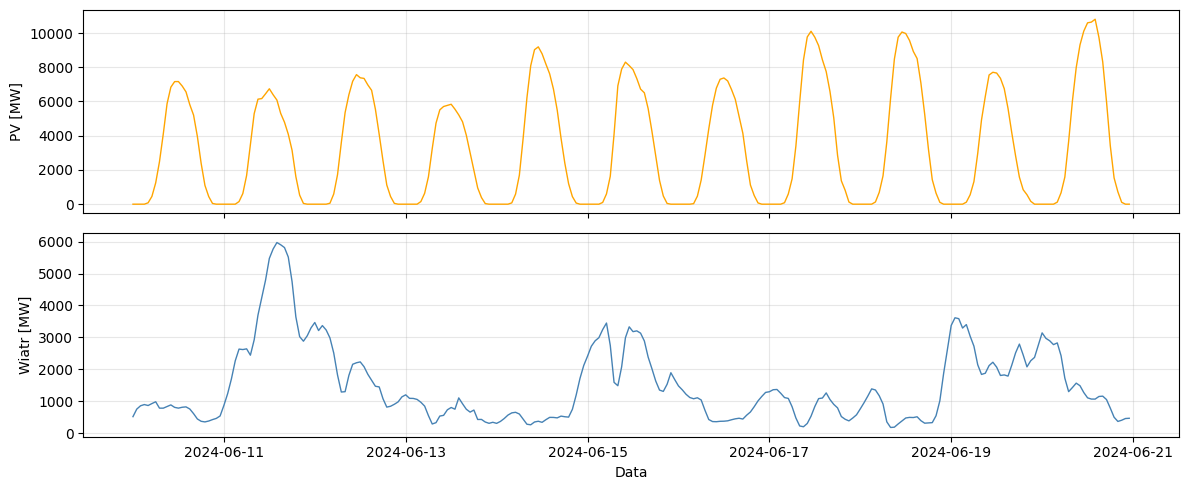

In [33]:
sample = df.loc["2024-06-10":"2024-06-20"]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(sample.index, sample["pv"], color="orange", lw=1)
axes[0].set_ylabel("PV [MW]")
axes[1].plot(sample.index, sample["wi"], color="steelblue", lw=1)
axes[1].set_ylabel("Wiatr [MW]")
axes[1].set_xlabel("Data")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Tydzień przejścia z archiwum CSV na API (~14 czerwca 2024). Krzywe są gładkie, brak skoku na styku obu źródeł.

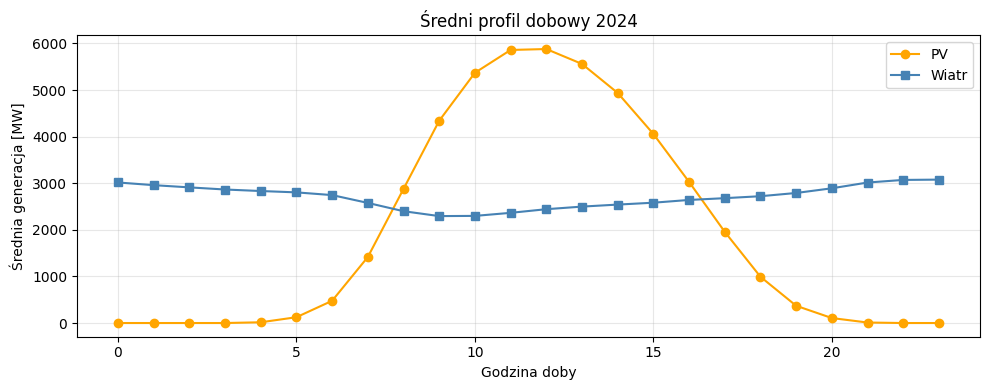

In [34]:
df_2024 = df.loc["2024"].copy()
df_2024["hour"] = df_2024.index.hour
profile = df_2024.groupby("hour")[["wi", "pv"]].mean()

fig, ax = plt.subplots(figsize=(10, 4))
profile["pv"].plot(ax=ax, color="orange", marker="o", label="PV")
profile["wi"].plot(ax=ax, color="steelblue", marker="s", label="Wiatr")
ax.set_xlabel("Godzina doby")
ax.set_ylabel("Średnia generacja [MW]")
ax.set_title("Średni profil dobowy 2024")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Średni profil dobowy: PV jako łuk z zerem w nocy i szczytem w południe, wiatr niemal płaski (typowa charakterystyka — wiatr nie ma silnej sezonowości dobowej).

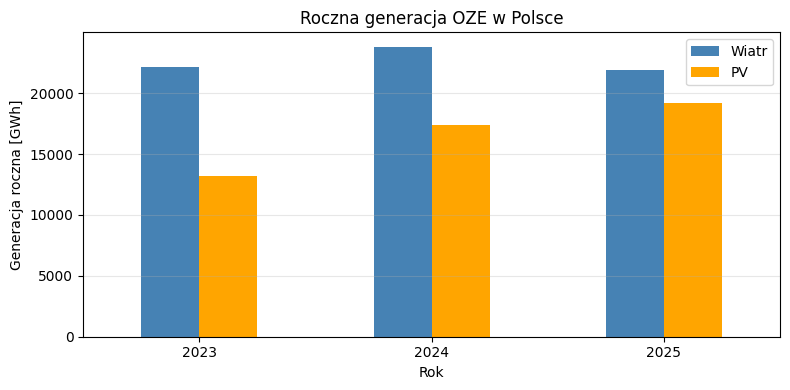

                wi       pv
timestamp                  
2023       22119.0  13224.0
2024       23802.0  17345.0
2025       21893.0  19229.0


In [35]:
yearly = df.groupby(df.index.year)[["wi", "pv"]].sum() / 1000  # GWh

fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(kind="bar", ax=ax, color=["steelblue", "orange"])
ax.set_ylabel("Generacja roczna [GWh]")
ax.set_xlabel("Rok")
ax.set_title("Roczna generacja OZE w Polsce")
ax.legend(["Wiatr", "PV"])
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(yearly.round(0))

Roczne sumy generacji. PV rośnie szybko (13 → 17 → 19 TWh), wiatr stabilny (~22 TWh). Wartości zgodne z oficjalnymi raportami rocznymi PSE.

### Podsumowanie sekcji 2.1

Zbiór danych: **26 304 wiersze**, godzinowa generacja wiatrowa i fotowoltaiczna w KSE, okres 2023-01-01 → 2025-12-31. Dwa źródła (archiwum CSV + API PSE) sklejone, luki DST zinterpolowane, brak NaN-ów. Wartości zgodne z oficjalnymi raportami rocznymi PSE.

Plik wynikowy: `data/processed/pse_oze_2023_2025.csv`.